# Modeling KBest - KNN - Hugo Fiévet

## Table of Contents

1. [Objective](#1-objective)
2. [Baseline Model](#2-baseline-model)
3. [Hyperparameter Tuning](#3-hyperparameter-tuning)
4. [Final Evaluation](#4-final-evaluation)
5. [Model Limits](#5-model-limits)


## 1. Objective

Etablir une performance de référence du modèle avec ses paramètres par défaut avant optimisation des hyperparamètres.

## 2. Baseline Model

In [2]:
import pandas as pd
from sklearn.model_selection import cross_validate,GridSearchCV,StratifiedGroupKFold
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42

knn =  KNeighborsClassifier()

xtrain_KB = pd.read_csv("xtrain_KB.csv")
ytrain = pd.read_csv("ytrain.csv").squeeze("columns")
kepid_train = pd.read_csv("kepid_train.csv").squeeze("columns")

Stratified_G_Kfold_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(estimator=knn,X=xtrain_KB,y=ytrain,groups=kepid_train,scoring="f1_macro",return_train_score=True,cv=Stratified_G_Kfold_cv)
pd.DataFrame(cv_results)



,fit_time,score_time,test_score,train_score
0,0.025065,0.065519,0.659685,0.777342
1,0.023583,0.066307,0.680325,0.775774
2,0.024137,0.065708,0.685316,0.782142
3,0.023114,0.063429,0.703705,0.773449
4,0.023234,0.065463,0.692106,0.785528


In [3]:
print("Mean train score : ",cv_results["train_score"].mean())
print("Mean validation score",cv_results["test_score"].mean())

Mean train score :  0.7788468700268825
Mean validation score 0.6842274573231948


Le modèle KNN avec ses paramètres par défaut obtient un F1-macro moyen en validation d’environ 0,684 en validation croisée.

Les scores de validation varient entre environ 0,660 et 0,704, avec un écart-type d’environ 0,015, ce qui indique des performances relativement stables entre les différents folds.

Le F1-macro moyen sur les données d’entraînement est d’environ 0,779, soit un écart d’environ 0,095 avec la validation.

Cet écart montre un surapprentissage modéré : le modèle est plus performant sur les données utilisées pour son entraînement que sur les observations de validation, mais le phénomène est nettement moins marqué que pour les Decision Trees ou les Random Forest non optimisés.

Cette baseline servira de référence pour évaluer si l’optimisation de n_neighbors, de la pondération des voisins et de la métrique de distance permet d’améliorer la généralisation du KNN

## 3. Hyperparameter Tuning

In [4]:
settings_grid = {
   "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "p":[1,2]
}

grid_search = GridSearchCV(estimator=knn,param_grid=settings_grid,scoring="f1_macro",cv=Stratified_G_Kfold_cv,return_train_score=True)

grid_search.fit(
    X=xtrain_KB,
    y=ytrain,
    groups=kepid_train
)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,StratifiedGro... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,11


In [5]:
best_index = grid_search.best_index_

print("Best parameters:", grid_search.best_params_)

print("Best validation F1:", grid_search.best_score_)
print(
    "Mean train F1:",
    grid_search.cv_results_["mean_train_score"][best_index]
)
print(
    "Std validation F1:",
    grid_search.cv_results_["std_test_score"][best_index]
)

Best parameters: {'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best validation F1: 0.697044922454116
Mean train F1: 0.7488643078525477
Std validation F1: 0.011113433993395516


L'optimisation du KNN sélectionne n_neighbors=11, p=1 et une pondération uniforme des voisins. Le F1-macro moyen en validation passe d'environ 0,684 pour la baseline à 0,697 après optimisation, tandis que le F1-macro d'entraînement diminue d'environ 0,779 à 0,749.

L'écart entre les performances d'entraînement et de validation est ainsi réduit d'environ 0,095 à 0,052, ce qui indique une diminution du surapprentissage et une meilleure capacité de généralisation.

L'augmentation du nombre de voisins de 5 à 11 rend la décision du KNN moins sensible aux observations très locales. De plus, p=1 correspond à la distance de Manhattan, qui s'avère ici plus adaptée que la distance euclidienne utilisée par défaut.

Enfin, l'écart-type du F1-macro en validation est d'environ 0,011, ce qui indique des performances relativement stables entre les différents folds

## 4. Final Evaluation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
X_test_KB = pd.read_csv("xtest_KB.csv")
y_test = pd.read_csv("ytest.csv").squeeze("columns")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X=X_test_KB)

class_report = classification_report(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy :",accuracy )
print("Precision macro :",precision )
print("Recall macro :",recall )
print("F1 macro :", f1)

Accuracy : 0.7281808622502629
Precision macro : 0.6884990342699192
Recall macro : 0.6995534877392827
F1 macro : 0.6909095450401508


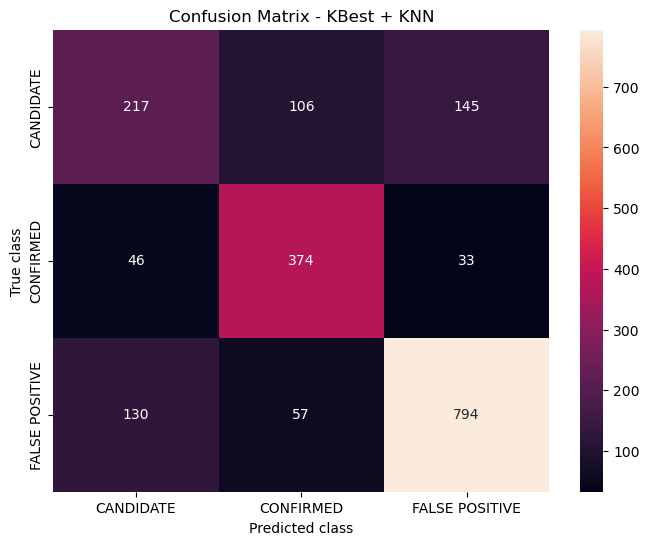

In [8]:
labels = ["CANDIDATE", "CONFIRMED", "FALSE POSITIVE"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix - KBest + KNN")

plt.show()

La matrice de confusion montre que le modèle KNN optimisé reconnaît correctement les classes CONFIRMED et FALSE POSITIVE, tandis que la classe CANDIDATE reste nettement plus difficile à identifier.

Parmi les 468 CANDIDATE, seulement 217 sont correctement classés. Le modèle en confond 106 avec CONFIRMED et surtout 145 avec FALSE POSITIVE. Cette classe constitue donc la principale source d’erreurs du modèle.

Pour les 453 CONFIRMED, 374 sont correctement identifiés, contre seulement 46 prédits CANDIDATE et 33 FALSE POSITIVE. Le modèle distingue donc particulièrement bien les exoplanètes confirmées.

Enfin, parmi les 981 FALSE POSITIVE, 794 sont correctement classés. Les erreurs concernent principalement 130 observations classées comme CANDIDATE, tandis que seulement 57 sont classées CONFIRMED.

Le modèle distingue donc relativement bien les cas les plus clairement CONFIRMED ou FALSE POSITIVE, mais rencontre davantage de difficultés avec les objets au statut CANDIDATE

## 5. Model Limits

La difficulté à prédire la classe CANDIDATE pourrait ne pas être uniquement liée aux limites du modèle. Un candidat KOI possède par définition un statut encore incertain et peut présenter des caractéristiques proches aussi bien des objets confirmés que des faux positifs. Cette ambiguïté intrinsèque pourrait expliquer une partie des confusions observées